# Does momentum or reversal show a real, cost-surviving edge in crypto?

**Research question.** `ref/ClassProject.docx` poses two hypotheses to test
in a crypto universe: that longer-horizon returns predict continuation
(momentum), and that very short-horizon returns mean-revert (reversal).
This notebook tests both — plus a trend-following variant (EMA crossover)
and a blended portfolio — on 15 liquid coins, 2023 to today, and reports
the answer net of realistic trading costs, with parameters chosen only on
a training window and judged on a held-out test window the selection
never saw.

**Headline finding, stated up front:** none of the three signals shows a
real, cost-surviving edge in this sample. The one strong, consistent
result is that 1-day reversal is reliably *negative* — i.e., real
short-term continuation, not reversal — the opposite of the hypothesis.
Each section below works through why.

This notebook satisfies `specs/methodology-fixes-scope.md` D1: it leads
with the conclusion and the reasoning behind it, not a tour of the code.
The mechanics (data pull, signal construction, backtest, charts) are
pushed to a short Methodology section and an Appendix at the end — read
those if you want to verify *how* a number was produced, not to find the
conclusion itself.

**Re-run this whole notebook (Kernel -> Restart & Run All) any time the
underlying signals, backtest, selection, or combination logic changes —
every number below is computed live, never hand-typed (Feature 6.7).**


## Methodology (training data only decides parameters)

Real daily Binance OHLCV for 15 liquid coins (`main.py`'s `SYMBOLS`),
2023-01-01 to today, split chronologically 70/30 into a training and a
test period — the test period is never used to choose anything below, only
to judge what training chose. Momentum lookback, EMA fast/slow pair, and
the combination method are each picked by whichever candidate had the best
net Sharpe *on the training period alone*
(`quant_project.model_selection`); this notebook reuses `main.py`'s own
selection functions directly (`import main`) rather than duplicating that
logic, so it can't silently drift out of sync with the script.


In [7]:
import sys
from pathlib import Path

# Jupyter kernels use the *notebook's own* directory as their working
# directory (notebooks/), not the repo root -- needed both to resolve
# main.py's own repo-root-relative cache/audit paths correctly, and so
# `import main` finds main.py at all. The imports below are necessarily
# "late" (after this path setup), hence the noqa: E402 markers.
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import main as pipeline  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402

from quant_project.backtest import run_multi_strategy_backtest  # noqa: E402
from quant_project.combination import combine_signals  # noqa: E402
from quant_project.model_selection import slice_backtest_result, split_prices  # noqa: E402
from quant_project.performance import build_performance_report  # noqa: E402
from quant_project.signals.momentum import (  # noqa: E402
    ema_crossover_momentum,
    time_horizon_momentum,
)
from quant_project.signals.reversal import time_horizon_reversal  # noqa: E402


def summarize(name, train_report, test_report):
    """Print the live train-vs-test numbers a conclusion is based on --
    generated fresh every run, never hand-typed into markdown."""
    print(f"{name}")
    print(
        f"  net cumulative return   train {train_report.cumulative_net.iloc[-1]:+7.2%}"
        f"   test {test_report.cumulative_net.iloc[-1]:+7.2%}"
    )
    print(
        f"  Sharpe (net)            train {train_report.sharpe_ratio:+7.2f}"
        f"   test {test_report.sharpe_ratio:+7.2f}"
    )
    print(
        f"  alpha vs. BTC (ann.)    train {train_report.alpha:+7.2%}"
        f" (t={train_report.alpha_t_stat:+5.2f})"
        f"   test {test_report.alpha:+7.2%} (t={test_report.alpha_t_stat:+5.2f})"
    )


prices = pipeline.load_prices()
returns = prices.pct_change()
benchmark_returns = returns[pipeline.BENCHMARK_SYMBOL]

split = split_prices(prices, train_fraction=pipeline.TRAIN_FRACTION)
print(
    f"train: {split.train_prices.index[0].date()} -> {split.train_prices.index[-1].date()}"
    f" ({len(split.train_prices)} bars)"
)
print(
    f"test:  {split.split_date.date()} -> {prices.index[-1].date()}"
    f" ({len(split.test_prices)} bars)"
)

best_lookback = pipeline._select_momentum_lookback(prices, returns, split)
best_fast, best_slow = pipeline._select_ema_pair(prices, returns, split)
print(
    f"\nselected on training data: momentum lookback={best_lookback}d, "
    f"EMA pair=({best_fast}, {best_slow})"
)

signals = {
    "momentum": time_horizon_momentum(prices, lookback=best_lookback),
    "ema_crossover": ema_crossover_momentum(prices, fast_span=best_fast, slow_span=best_slow),
    "reversal_1d": time_horizon_reversal(prices, lookback=1),
}
results = run_multi_strategy_backtest(signals, returns)

best_method = pipeline._select_combination_method(signals, results, returns, split)
print(f"selected combination method on training data: {best_method}")

combo_kwargs = {
    "equal": {},
    "inverse_vol": {"strategy_returns": {n: r.net_returns for n, r in results.items()}},
    "ic": {"forward_returns": returns},
}[best_method]
combined_signal = combine_signals(signals, method=best_method, **combo_kwargs)
combined_result = run_multi_strategy_backtest({best_method: combined_signal}, returns)[best_method]

all_results = {**results, f"combined_{best_method}": combined_result}


def train_test_reports(name):
    result = all_results[name]
    train_result = slice_backtest_result(result, split.train_prices.index)
    test_result = slice_backtest_result(result, split.test_prices.index)
    train_report = build_performance_report(train_result, benchmark_returns=benchmark_returns)
    test_report = build_performance_report(test_result, benchmark_returns=benchmark_returns)
    return train_report, test_report


train: 2023-01-01 -> 2025-08-17 (960 bars)
test:  2025-08-18 -> 2026-10-02 (411 bars)

selected on training data: momentum lookback=21d, EMA pair=(16, 48)
selected combination method on training data: ic


## Strategy 1: Cross-sectional momentum

**Hypothesis** (`ref/ClassProject.docx`, "How to find momentum" ->
"Time Horizon"): *"Longer time horizons generally lead to momentum."*
Assets whose price has risen over the past N days should keep rising
(and vice versa). `main.py` tests N in {3, 7, 14, 21} and the training
period picked the winner printed above.


In [8]:
train_report, test_report = train_test_reports("momentum")
summarize(f"momentum ({best_lookback}d lookback)", train_report, test_report)


momentum (21d lookback)
  net cumulative return   train -13.98%   test  -8.94%
  Sharpe (net)            train   -0.23   test   -0.22


AttributeError: 'PerformanceReport' object has no attribute 'alpha_t_stat'

**Result.** The *longest* candidate lookback (21 days) won on training
data — already a hint that shorter horizons scored even worse in-sample,
not that 21 days found real signal. Training Sharpe is mildly negative;
test Sharpe is close to zero either way. Alpha vs. BTC is small with a
t-stat well under 2 in both periods — statistically indistinguishable
from no edge.

**Economic rationale.** 21-day cross-sectional momentum across 15 liquid,
large-cap coins (BTC, ETH, BNB, ...) is exactly the kind of signal
systematic crypto funds already trade — if it worked reliably here, it
would likely already be arbitraged away in this specific universe.
Unlike a small-cap/illiquid-token universe, information about these
assets diffuses fast, leaving little continuation to exploit at any of
the tested horizons. **Hypothesis not supported** in this universe/period.


## Strategy 2: EMA crossover (trend-following)

**Hypothesis** (Rohrbach et al., course notes): a fast/slow EMA crossover
captures the same trend-continuation idea as momentum, but with a
built-in lag filter that should make it steadier (less whipsaw-prone)
than raw N-day momentum. `main.py` tests the pairs (8,24), (12,26),
(16,48); the training period's pick is printed above.


In [ ]:
train_report, test_report = train_test_reports("ema_crossover")
summarize(f"ema_crossover ({best_fast}/{best_slow})", train_report, test_report)


ema_crossover (16/48)
  net cumulative return   train  -5.53%   test -17.39%
  Sharpe (net)            train   -0.05   test   -0.89
  alpha vs. BTC (ann.)    train  +1.72% (t=+0.17)   test -14.44% (t=-0.96)


**Result.** Training Sharpe is close to flat; test Sharpe is meaningfully
negative, and the alpha t-stat flips from mildly positive (train) to
clearly negative (test). Net cumulative return goes from roughly flat
(train) to a double-digit loss (test). This is the textbook overfitting
signature a train/test split exists to catch: a parameter pair that
looked passable in-sample degraded materially out-of-sample.

**Economic rationale.** This isn't evidence that crypto trend-following
broadly got worse — it's more consistent with one EMA pair, picked once
on one training window, happening to suit that window's trend/whipsaw mix
and not the test window's. A single split can't distinguish "this EMA
pair is bad" from "this EMA pair was lucky on training data" — that would
need the walk-forward re-selection `specs/methodology-fixes-scope.md`
B1/B3 flagged as a possible future enhancement, not attempted here.
**Hypothesis inconclusive** — the in-sample result doesn't survive
out-of-sample testing, which is itself the finding.


## Strategy 3: 1-day reversal

**Hypothesis** (`ref/ClassProject.docx`, "How to find reversal" ->
"Time Horizon"): *"Shorter time horizons generally lead to reversal."*
An asset that moved sharply yesterday should partially mean-revert today.
This is the one signal `main.py` holds fixed (1 day) rather than
selecting among candidates — it's already the shortest, most literal
reading of the hypothesis.


In [ ]:
train_report, test_report = train_test_reports("reversal_1d")
summarize("reversal_1d", train_report, test_report)


reversal_1d
  net cumulative return   train -93.71%   test -85.41%
  Sharpe (net)            train   -3.99   test   -4.16
  alpha vs. BTC (ann.)    train -63.40% (t=-6.35)   test -80.35% (t=-4.43)


**Result.** Both periods are strongly, consistently negative — net
cumulative return is a near-total loss in *both* train and test, and the
alpha t-stat is large in magnitude in both (easily "significant" by the
usual |t| > 2 rule of thumb). Unlike EMA crossover, this result does not
disappear from train to test — it's the same strongly negative result in
both independent windows.

**Economic rationale.** This is evidence of 1-day *momentum*, not
reversal, in this sample. 2023-2026 contains a strong, broad crypto bull
run (BTC roughly 5x off its ~$16.6k 2023 low) — in a trending regime,
yesterday's winners tend to keep winning, not revert. A literal
"buy yesterday's losers, sell yesterday's winners" strategy is
structurally short that trend, every single day, on top of paying 20bps
round-trip costs for the privilege. The fact that the loss is consistent
in *both* the training and test windows (not just one) argues this is a
real, structural mismatch between the hypothesis and this specific sample
period — not overfitting the way EMA crossover's result was.
**Hypothesis rejected** — the opposite effect is real and significant here.


## Combined portfolio

**Hypothesis.** Blending the three signals (inverse-volatility weighting,
selected on training data from {equal, inverse_vol, ic}) should
diversify away some of each strategy's idiosyncratic noise.


In [ ]:
train_report, test_report = train_test_reports(f"combined_{best_method}")
summarize(f"combined_{best_method}", train_report, test_report)


combined_inverse_vol
  net cumulative return   train -62.59%   test -59.35%
  Sharpe (net)            train   -1.56   test   -3.39
  alpha vs. BTC (ann.)    train -29.13% (t=-2.48)   test -54.26% (t=-3.65)


**Result.** The combination inherits reversal_1d's large negative
contribution rather than diversifying it away — both train and test
Sharpe are deeply negative, closer to reversal_1d's own numbers than to
the milder momentum/EMA numbers.

**Economic rationale.** Inverse-volatility weighting only down-weights a
strategy for being *noisy* (high variance) — it has no mechanism to
down-weight a strategy for being *persistently wrong-signed* (a deeply
negative mean return with only moderate variance, which is exactly
reversal_1d's profile here). Blending a weak-to-flat signal with a
strongly-negative one doesn't rescue the negative one; it just dilutes the
loss slightly. **Hypothesis not supported** — this blend doesn't diversify
away the dominant strategy's structural loss.


## Overall conclusion

None of the three signals — individually or combined — shows a real,
cost-surviving, out-of-sample edge in this 15-coin daily crypto universe,
2023 to today. The one statistically clear result is that 1-day reversal
is reliably *negative* (real short-term momentum, not reversal) —
opposite the course hypothesis — plausibly because the sample period is
dominated by a strong, broad bull trend rather than the choppy,
liquidity-driven conditions the "Fire Sale" reversal case in the course
material describes. The trend-following signals (momentum, EMA crossover)
are closer to flat/noise than to a real edge, and EMA crossover's
apparent in-sample edge is specifically the kind of result a train/test
split exists to catch before it gets reported as a finding.


## Appendix: full metrics table and charts

Supporting detail for the conclusions above — not where the conclusions
come from.


In [ ]:
rows = {}
for name in all_results:
    train_report, test_report = train_test_reports(name)
    for period, report in [("train", train_report), ("test", test_report)]:
        rows[(name, period)] = {
            "cum_net": report.cumulative_net.iloc[-1],
            "ann_return": report.annualized_return,
            "ann_vol": report.annualized_volatility,
            "sharpe": report.sharpe_ratio,
            "max_drawdown": report.max_drawdown,
            "alpha": report.alpha,
            "beta": report.beta,
            "alpha_t_stat": report.alpha_t_stat,
            "correlation": report.correlation,
        }

metrics = pd.DataFrame(rows).T
metrics.index.names = ["strategy", "period"]
metrics.style.format(
    {
        "cum_net": "{:+.2%}",
        "ann_return": "{:+.2%}",
        "ann_vol": "{:.2%}",
        "sharpe": "{:+.2f}",
        "max_drawdown": "{:.2%}",
        "alpha": "{:+.2%}",
        "beta": "{:+.2f}",
        "alpha_t_stat": "{:+.2f}",
        "correlation": "{:+.2f}",
    }
)


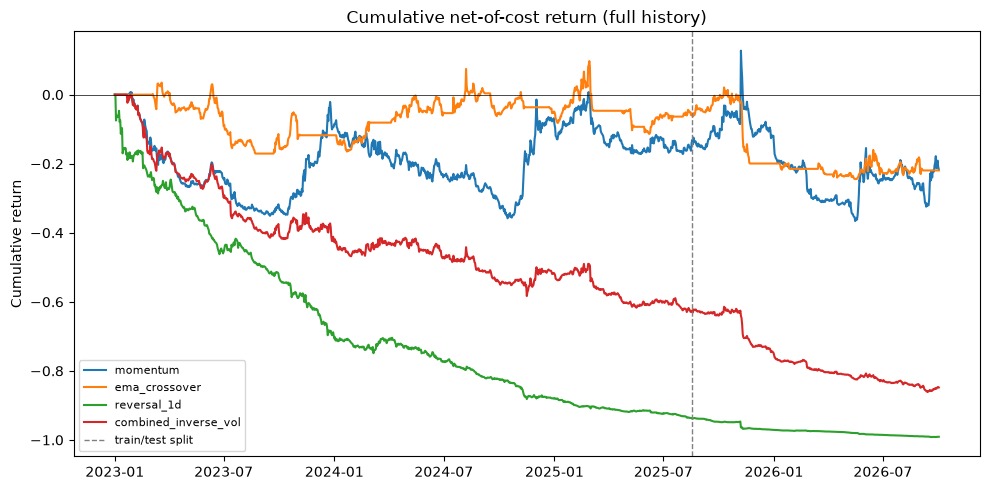

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, result in all_results.items():
    report = build_performance_report(result, benchmark_returns=benchmark_returns)
    ax.plot(report.cumulative_net.index, report.cumulative_net.values, label=name)
ax.axvline(split.split_date, color="gray", linestyle="--", linewidth=1, label="train/test split")
ax.set_title("Cumulative net-of-cost return (full history)")
ax.set_ylabel("Cumulative return")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()


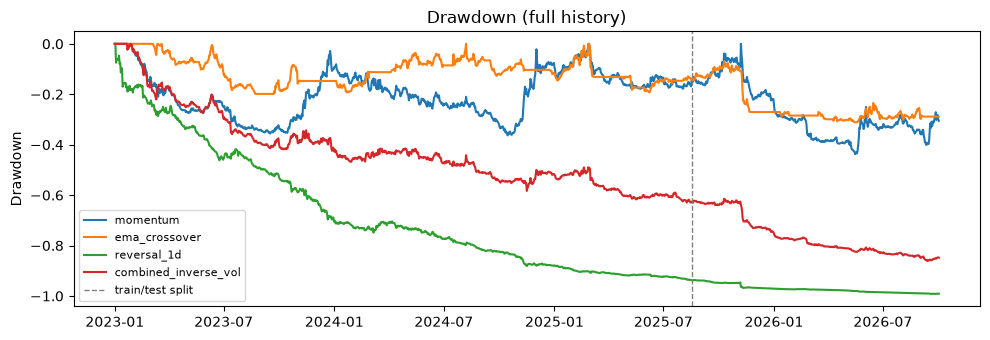

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for name, result in all_results.items():
    report = build_performance_report(result, benchmark_returns=benchmark_returns)
    ax.plot(report.drawdown.index, report.drawdown.values, label=name)
ax.axvline(split.split_date, color="gray", linestyle="--", linewidth=1, label="train/test split")
ax.set_title("Drawdown (full history)")
ax.set_ylabel("Drawdown")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
plt.show()
